# 03 — Applying the paper objects to the pipeline's own telemetry

**This is a synthetic portfolio starting point, not production evidence.** Notebook 03 consumes the artifacts of
`02_project_walkthrough_part1.ipynb` instead of regenerating anything: the same 320-row teacher-student task, the same
train-only pre-processing, the same seeded runs. Its job is the observability layer — online incident diagnosis with
no hindsight, a seed-aware audit, abstention accounting, and the cached-rerun cost history.

Scope boundaries that stay open on purpose: no transfer claim to an `adaptive optimizer`, to a `non-quadratic` loss,
or to financial `time-series`; no production `false-alarm` or miss-rate guarantee; no `paired-seed power` calculation;
the `operational cost` rate used by the ledger is a stated assumption, not a measurement. Those are
left out of scope here.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "exec" / "common.py").is_file():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

%matplotlib inline
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

from exec import common
from exec.walkthrough import pipeline as nb2_pipeline

ROOT = common.PROJECT_ROOT
print("project root:", ROOT)
print("numpy", np.__version__, "| matplotlib", matplotlib.__version__)
print("reuse target:", ROOT / "notebooks" / "02_project_walkthrough_part1.ipynb")

project root: /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-3/training-dynamics-observability
numpy 2.5.3 | matplotlib 3.11.2
reuse target: /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-3/training-dynamics-observability/notebooks/02_project_walkthrough_part1.ipynb


## Data understanding — what NB3 reuses

Notebook 02 built a synthetic teacher-student task with a known latent optimum, 320 rows, a high-noise hard regime
and a genuinely mixed ambiguous regime, then revealed the latent truth only after each online decision point. NB3
does not re-derive any of it: it reads NB2's published `task_truth` and the cached rows, and treats the seeded
generation as fixed evidence. The `seed` recorded in NB2's `preprocessing` block is the identity NB3 checks against.

In [2]:
published = nb2_pipeline.load_published()
truth = published["task_truth"]
rows = nb2_pipeline.load_dataset()
print(f"rows reused from NB2: {len(rows)} (regenerated by NB3: {nb2_pipeline.DATA_REGENERATED_BY_NB3})")
print("task_kind:", truth["task_kind"], "| signal_strength:", round(truth["signal_strength"], 4),
      "| irreducible_noise:", round(truth["irreducible_noise"], 4))
print("observable features:", truth["observable_feature_count"], "| hard regimes:", truth["hard_regimes"],
      "| ambiguous regimes:", truth["ambiguous_regimes"])
common.selfcheck(1, len(rows) >= 200 and nb2_pipeline.DATA_REGENERATED_BY_NB3 is False,
                 "the cached NB2 dataset is reused without regeneration")
common.selfcheck(2, truth["known_optimum"] is not None and 0 < truth["signal_strength"] < 1,
                 "latent truth is present and the signal strength is interior")

rows reused from NB2: 320 (regenerated by NB3: False)
task_kind: teacher_student | signal_strength: 0.6239 | irreducible_noise: 0.5811
observable features: 6 | hard regimes: ['low_margin_high_noise'] | ambiguous regimes: ['boundary_margin']
SELF-CHECK 1 [MET] the cached NB2 dataset is reused without regeneration
SELF-CHECK 2 [MET] latent truth is present and the signal strength is interior


True

## Pre-processing — reused, never refit

NB2 fit its normalization on training rows only and published the row split. NB3 cannot silently reintroduce a
leakage path, so it recomputes the canonical hash of the cached rows and compares it with the published
`data_hash`. Equality proves the reused rows are byte-identical to NB2's artifact — this is a project choice
(`derived here` from the frozen contract), not something the papers specify.

In [3]:
prep = published["preprocessing"]
cached_hash = nb2_pipeline.dataset_data_hash()
print("published fit_scope:", prep["fit_scope"], "| fit/eval rows:", len(prep["fit_rows"]), "/", len(prep["evaluation_rows"]))
print("published data_hash:", prep["data_hash"])
print("recomputed hash   :", cached_hash)
common.selfcheck(3, cached_hash == prep["data_hash"], "the reused rows hash to NB2's published data hash")
common.selfcheck(4, set(prep["fit_rows"]).isdisjoint(prep["evaluation_rows"]) and prep["fit_scope"] == "train_only",
                 "pre-processing stayed train-only and is reused, not refit")

published fit_scope: train_only | fit/eval rows: 224 / 96
published data_hash: 18d2a432e2f86535ae863e95f9f1f78dd350331c72457956dad1c7c4f20fb7e8
recomputed hash   : 18d2a432e2f86535ae863e95f9f1f78dd350331c72457956dad1c7c4f20fb7e8
SELF-CHECK 3 [MET] the reused rows hash to NB2's published data hash
SELF-CHECK 4 [MET] pre-processing stayed train-only and is reused, not refit


True

## Training — the runs NB3 consumes

Every NB2 run is in the ledger with a seed, a data hash and a config hash. NB3 identifies the generation runs whose
hashes match the data it is reading; those run ids become the provenance of the reused pipeline. This is the
project's `operational cost` bookkeeping too: each row carries its wall-clock time and an assumed cost under a
stated `1.50 USD per GPU-hour` assumption, labelled as an assumption rather than an invoice.

In [4]:
from exec.common import Timer, load_ledger

with Timer() as timer:
    shared = nb2_pipeline.shared_run_ids()
    data_hash = nb2_pipeline.dataset_data_hash()
    config_hash = nb2_pipeline.generation_config_hash()

ledger_rows = {row["run_id"]: row for row in load_ledger()}
provenance_ok = all(
    rid in ledger_rows
    and ledger_rows[rid]["data_hash"] == data_hash
    and ledger_rows[rid]["config_hash"] == config_hash
    for rid in shared
)
for rid in shared:
    row = ledger_rows[rid]
    print(f"{rid}: notebook {row['notebook']} | seed {row['seed']} | wall {row['wall_time_s']:.3f}s | "
          f"assumed ${row['assumed_cost_usd']:.3e}")
print("cost assumption:", ledger_rows[shared[0]]["cost_assumption"])
common.selfcheck(5, bool(shared) and provenance_ok,
                 f"{len(shared)} NB2 run ids carry this data/config hash in the ledger")

nb2_path = ROOT / "notebooks" / "02_project_walkthrough_part1.ipynb"
nb2_sha = common.sha256_file(nb2_path)
print("NB2 notebook sha256:", nb2_sha)

nb2-task-generation: notebook 02 | seed 20260921 | wall 0.069s | assumed $2.894e-05
nb2-task-generation-repeat: notebook 02 | seed 20260921 | wall 0.020s | assumed $8.397e-06
cost assumption: assumed cost = wall-clock seconds x USD 1.50 per GPU-hour (a stated T4-class cloud-rate assumption, not a measured invoice)
SELF-CHECK 5 [MET] 2 NB2 run ids carry this data/config hash in the ledger
NB2 notebook sha256: 2d4a51f1faf762a7a656e9316957987c79bc6f50b7a9b6fb2ff61e31e86f6932


## Post-training visualization — incident and cost evidence

The three charts below visualize evidence that already passed its checks: incident telemetry against the online
decision point, the paired-seed audit, and the cached-rerun cost history.

### How to read this chart — incident telemetry

Each line is one incident's loss trajectory; the dashed vertical line is that incident's online decision step.
Everything to the right of a dashed line was unavailable to the detector when it committed to its label, and the
ordinal step axis is shared, so escalation and same-run recovery are directly comparable. A curve that keeps rising
after its line is a true divergence; a curve whose minimum drops below its pre-decision minimum recovered without a
restart.

In [5]:
incidents = published["incident_bank"]["incidents"]
kinds = sorted({item["truth_kind"] for item in incidents})
print("incident kinds:", kinds)
for item in incidents:
    future = [point for point in item["telemetry"] if point["step"] > item["decision_step"]]
    print(f"{item['incident_id']}: kind {item['truth_kind']} | decision {item['decision_step']} | "
          f"post-decision points {len(future)} | label {item['online_diagnosis']['label']}")
common.selfcheck(6, {"true_divergence", "recoverable_transient_plateau", "seed_only_misleading_improvement",
                     "unresolved_mixed"} <= set(kinds),
                 "all four incident kinds are present in the reused bank")
common.selfcheck(7, all(point["step"] <= item["decision_step"]
                        for item in incidents for point in item["online_diagnosis"]["telemetry_inputs"]),
                 "every online diagnosis stayed inside its decision prefix")

incident kinds: ['recoverable_transient_plateau', 'seed_only_misleading_improvement', 'true_divergence', 'unresolved_mixed']
inc-divergence-01: kind true_divergence | decision 36 | post-decision points 28 | label divergence_risk
inc-plateau-01: kind recoverable_transient_plateau | decision 40 | post-decision points 44 | label wait_for_transient
inc-seed-only-01: kind seed_only_misleading_improvement | decision 55 | post-decision points 24 | label improving
inc-mixed-conflict-01: kind unresolved_mixed | decision 34 | post-decision points 36 | label abstain
inc-mixed-flat-01: kind unresolved_mixed | decision 30 | post-decision points 30 | label unresolved
SELF-CHECK 6 [MET] all four incident kinds are present in the reused bank
SELF-CHECK 7 [MET] every online diagnosis stayed inside its decision prefix


True

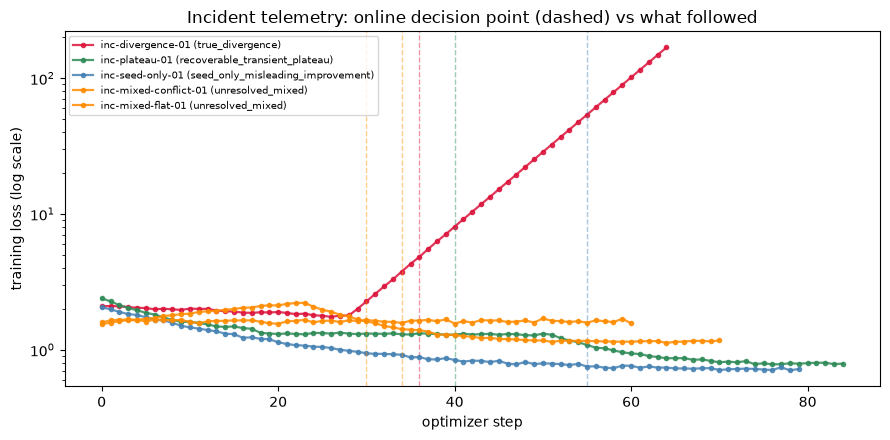

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = {"true_divergence": "crimson", "recoverable_transient_plateau": "seagreen",
          "seed_only_misleading_improvement": "steelblue", "unresolved_mixed": "darkorange"}
for item in incidents:
    steps = [point["step"] for point in item["telemetry"]]
    losses = [point["loss"] for point in item["telemetry"]]
    ax.plot(steps, losses, marker="o", ms=3, lw=1.6, alpha=0.85, color=colors[item["truth_kind"]],
            label=f"{item['incident_id']} ({item['truth_kind']})")
    ax.axvline(item["decision_step"], color=colors[item["truth_kind"]], ls="--", lw=1.0, alpha=0.45)
ax.set_yscale("log")
ax.set_xlabel("optimizer step")
ax.set_ylabel("training loss (log scale)")
ax.set_title("Incident telemetry: online decision point (dashed) vs what followed")
ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

### How to read this chart — seed audit

Each bar is one paired seed's difference between the candidate and the baseline on the same task. Bars on both
sides of the zero line mean the direction of the effect reverses with the seed, so a single-seed, best-of-N or
eyeballed claim can be made to say anything. The seed-aware summary therefore reports `unresolved` instead of a
winner.

In [7]:
audit = published["seed_audit"]
paired = audit["paired_seed_differences"]
values = [row["difference"] for row in paired]
print("paired seeds:", [row["seed"] for row in paired])
print("paired differences:", [round(value, 5) for value in values])
print("seed-aware summary:", audit["seed_aware_summary"]["status"], "|", audit["seed_aware_summary"]["claim"])
common.selfcheck(8, any(value > 0 for value in values) and any(value < 0 for value in values),
                 "paired seed differences reverse sign; single-seed claims stay misleading")

paired seeds: [0, 1, 2, 3, 4, 5, 6, 7]
paired differences: [0.00569, -0.02167, 0.00483, 0.02456, 0.04465, -0.00794, -0.01121, -0.06295]
seed-aware summary: unresolved | paired over 8 seeds, the mean difference in the mean_training_loss_over_last_20_steps between arm B and arm A is -0.0030 (95% interval [-0.0252, +0.0192]; 4 seeds favour B, 4 favour A); with no paired-seed power calculation the comparison is unresolved and no winner is certified
SELF-CHECK 8 [MET] paired seed differences reverse sign; single-seed claims stay misleading


True

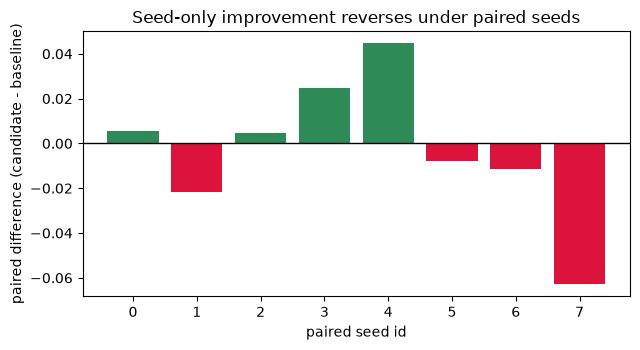

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
labels = [str(row["seed"]) for row in paired]
ax.bar(labels, values, color=["seagreen" if value > 0 else "crimson" for value in values])
ax.axhline(0.0, color="black", lw=1.0)
ax.set_xlabel("paired seed id")
ax.set_ylabel("paired difference (candidate - baseline)")
ax.set_title("Seed-only improvement reverses under paired seeds")
fig.tight_layout()
plt.show()

### How to read this chart — cached rerun cost

The two orange/green bars are the cached rerun's own tiny cache-hit cost and the historical cost it retains. A
cache hit must never report `$0`: the chart shows the original run's cost staying visible on the rerun record, which
is what keeps the historical `operational cost` auditable after the fact.

In [9]:
ledger_now = load_ledger()
cached = [row for row in ledger_now if row.get("cache_status") == "cached_rerun"]
originals = {row["run_id"]: row for row in ledger_now}
cached_row = cached[0]
original_row = originals[cached_row["reuses_run_id"]]
print(f"original {original_row['run_id']}: wall {original_row['wall_time_s']:.3f}s, assumed ${original_row['assumed_cost_usd']:.3e}")
print(f"cached   {cached_row['run_id']}: wall {cached_row['wall_time_s']:.3f}s, assumed ${cached_row['assumed_cost_usd']:.3e}")
print(f"historical retained: wall {cached_row['historical_wall_time_s']:.3f}s, "
      f"assumed ${cached_row['historical_assumed_cost_usd']:.3e}")
common.selfcheck(9, cached_row["historical_wall_time_s"] == original_row["wall_time_s"]
                 and cached_row["historical_assumed_cost_usd"] == original_row["assumed_cost_usd"]
                 and cached_row["historical_assumed_cost_usd"] > 0,
                 "a cached rerun keeps the original wall time and cost visible")

original nb2-task-generation: wall 0.069s, assumed $2.894e-05
cached   nb2-task-generation-cached: wall 0.054s, assumed $2.262e-05
historical retained: wall 0.069s, assumed $2.894e-05
SELF-CHECK 9 [MET] a cached rerun keeps the original wall time and cost visible


True

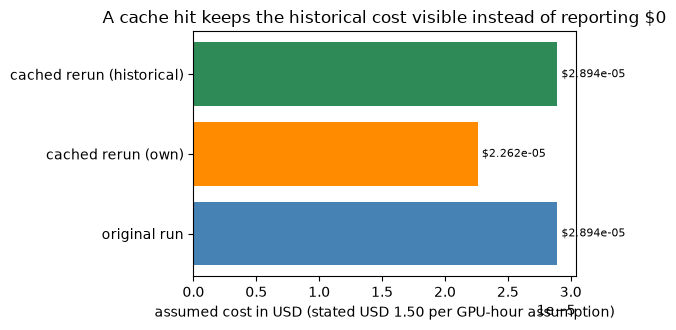

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
labels = ["original run", "cached rerun (own)", "cached rerun (historical)"]
costs = [original_row["assumed_cost_usd"], cached_row["assumed_cost_usd"], cached_row["historical_assumed_cost_usd"]]
bars = ax.barh(labels, costs, color=["steelblue", "darkorange", "seagreen"])
for bar, cost in zip(bars, costs):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f" ${cost:.3e}", va="center", fontsize=8)
ax.set_xlabel("assumed cost in USD (stated USD 1.50 per GPU-hour assumption)")
ax.set_title("A cache hit keeps the historical cost visible instead of reporting $0")
fig.tight_layout()
plt.show()

## Metric observability — abstentions kept visible

The after-action report scores only the incidents the online detector committed to; the unresolved mixed cases stay
in the report as `abstain`/`unresolved` rows and are excluded from the accuracy denominator. NB3 also publishes the
`reuse` block that pins the executed NB2 notebook bytes, and logs its own ledger row.

In [11]:
ACTIONS = {
    "true_divergence": ("restart from the last checkpoint",
                        "loss kept escalating after the decision; restarting was the right call"),
    "recoverable_transient_plateau": ("wait, do not restart",
                                      "loss recovered later in the same run, without a restart or a config change"),
    "seed_only_misleading_improvement": ("treat the improvement as unproven",
                                         "the paired seed differences reversed the direction"),
    "unresolved_mixed": ("abstain and escalate for review",
                         "the prefix was ambiguous; the case stays out of the scored denominator"),
}

after_action = []
for item in incidents:
    action, observed = ACTIONS[item["truth_kind"]]
    after_action.append({
        "incident_id": item["incident_id"],
        "online_label": item["online_diagnosis"]["label"],
        "truth_kind": item["truth_kind"],
        "action": action,
        "observed_result": observed,
    })

unresolved_rows = [row for row in after_action if row["truth_kind"] == "unresolved_mixed"]
accounting = {
    "unresolved_count": len(unresolved_rows),
    "scored_count": len(after_action) - len(unresolved_rows),
    "accuracy_denominator_excludes_unresolved": True,
}
for row in after_action:
    print(f"{row['incident_id']}: label {row['online_label']} -> {row['action']}")

reuse = {
    "nb2_notebook_sha256": nb2_sha,
    "pipeline_reused": True,
    "data_regenerated_by_nb3": nb2_pipeline.DATA_REGENERATED_BY_NB3,
    "shared_run_ids": shared,
    "data_hash": data_hash,
    "config_hash": config_hash,
}
published["reuse"] = reuse
published["incident_report"] = {"after_action_rows": after_action, "accounting": accounting}
common.write_json(ROOT / "exec" / "walkthrough_results.json", published)
print("published reuse + incident_report; NB2 sha256", reuse["nb2_notebook_sha256"][:16], "...")
print("accounting:", accounting)

common.selfcheck(10, accounting["unresolved_count"] == len(unresolved_rows)
                 and accounting["unresolved_count"] + accounting["scored_count"] == len(after_action),
                 "unresolved cases are counted separately and reconcile with the after-action rows")
common.selfcheck(11, all(row["online_label"] in {"abstain", "unresolved"} for row in unresolved_rows),
                 "unresolved incidents remain abstentions, not error-bucket entries")
common.selfcheck(12, reuse["pipeline_reused"] and not reuse["data_regenerated_by_nb3"],
                 "NB3 reused NB2's pipeline instead of regenerating the task")

row = common.make_run("nb3-reuse-verification", "03", int(nb2_pipeline.generation_config()["seed"]),
                      data_hash, config_hash, reuse, timer.elapsed)
common.append_runs([row])
print("ledger row appended:", row["run_id"], f"| wall {row['wall_time_s']:.3f}s | assumed ${row['assumed_cost_usd']:.3e}")

inc-divergence-01: label divergence_risk -> restart from the last checkpoint
inc-plateau-01: label wait_for_transient -> wait, do not restart
inc-seed-only-01: label improving -> treat the improvement as unproven
inc-mixed-conflict-01: label abstain -> abstain and escalate for review
inc-mixed-flat-01: label unresolved -> abstain and escalate for review
published reuse + incident_report; NB2 sha256 2d4a51f1faf762a7 ...
accounting: {'unresolved_count': 2, 'scored_count': 3, 'accuracy_denominator_excludes_unresolved': True}
SELF-CHECK 10 [MET] unresolved cases are counted separately and reconcile with the after-action rows
SELF-CHECK 11 [MET] unresolved incidents remain abstentions, not error-bucket entries
SELF-CHECK 12 [MET] NB3 reused NB2's pipeline instead of regenerating the task
ledger row appended: nb3-reuse-verification | wall 0.014s | assumed $5.695e-06


## Telemetry perturbation stability

The R2 replay perturbed the detector's *thresholds*. Round 3 perturbs only the *telemetry*: three operators (`gaussian_noise`, `scale_drift`, `observation_dropout`) at strengths `0.00, 0.01, 0.03, 0.05`, five seeds (`501..505`), across all five incidents — 300 attempts, each with a distinct causal run id, a base/perturbed prefix pair, and both labels recomputable by the same prefix-only detector that NB2 introduced. Stability (perturbed label equals the unperturbed label) and abstention are separate 95% Wilson rates over all 25 attempts per cell, and no accuracy, false-alarm or production field is produced.

**Question:** which telemetry-only perturbations move the online label, and do the ambiguous incidents keep abstaining rather than being forced into a call?

In [12]:
from exec.walkthrough import incidents

telemetry_payload = incidents.round03_telemetry_audit()
print("attempts:", len(telemetry_payload["attempt_rows"]), "| configurations:", len(telemetry_payload["configurations"]))
for rate in telemetry_payload["stability_rates"]:
    print(f"  {rate['operator']:>18s} strength={rate['strength']:.2f} "
          f"stability={rate['stability_count']}/{rate['stability']['attempts']} "
          f"abstention={rate['abstention_count']}/{rate['abstention']['attempts']}")

attempts: 300 | configurations: 300
      gaussian_noise strength=0.00 stability=25/25 abstention=10/25
      gaussian_noise strength=0.01 stability=25/25 abstention=10/25
      gaussian_noise strength=0.03 stability=24/25 abstention=11/25
      gaussian_noise strength=0.05 stability=20/25 abstention=13/25
         scale_drift strength=0.00 stability=25/25 abstention=10/25
         scale_drift strength=0.01 stability=25/25 abstention=10/25
         scale_drift strength=0.03 stability=25/25 abstention=10/25
         scale_drift strength=0.05 stability=20/25 abstention=15/25
  observation_dropout strength=0.00 stability=25/25 abstention=10/25
  observation_dropout strength=0.01 stability=23/25 abstention=12/25
  observation_dropout strength=0.03 stability=22/25 abstention=13/25
  observation_dropout strength=0.05 stability=20/25 abstention=12/25


In [13]:
rows = telemetry_payload["attempt_rows"]
subset = [row for row in rows if row["operator"] == "gaussian_noise" and row["strength"] == 0.05]
stable = sum(row["label"] == row["base_label"] for row in subset)
abstained = sum(row["label"] in {"abstain", "unresolved"} for row in subset)
published = next(
    rate for rate in telemetry_payload["stability_rates"]
    if rate["operator"] == "gaussian_noise" and rate["strength"] == 0.05
)
low, high = common.wilson_95(stable, len(subset))
low_a, high_a = common.wilson_95(abstained, len(subset))
counts_ok = published["stability_count"] == stable and published["abstention_count"] == abstained
wilson_ok = (
    abs(low - float(published["stability"]["wilson_95"]["low"])) < 1e-12
    and abs(high - float(published["stability"]["wilson_95"]["high"])) < 1e-12
    and abs(low_a - float(published["abstention"]["wilson_95"]["low"])) < 1e-12
    and abs(high_a - float(published["abstention"]["wilson_95"]["high"])) < 1e-12
)
zero_strength_ok = all(
    row["label"] == row["base_label"] and row["perturbed_prefix"] == row["base_prefix"]
    for row in rows if float(row["strength"]) == 0.0
)
common.selfcheck(
    13,
    counts_ok and wilson_ok and zero_strength_ok,
    f"one cell recomputes ({stable}/{len(subset)} stable, {abstained} abstained) with exact Wilson endpoints; zero strength is byte-identical",
)

SELF-CHECK 13 [MET] one cell recomputes (20/25 stable, 13 abstained) with exact Wilson endpoints; zero strength is byte-identical


True

## What is still open — limitations

- Transfer to an `adaptive optimizer` is out of scope; nothing here says Adam would behave the same.
- `non-quadratic` losses and financial `time-series` are outside the evidence; both are out of scope.
- No `paired-seed power` calculation or minimum detectable effect exists — that is left for future work.
- A quiet detector is not a certificate: there is no production `false-alarm` or miss-rate guarantee.
- The `operational cost` rate is a stated assumption; swapping in a real invoice rate is left to the reader.

This notebook is a synthetic portfolio starting point, not production experience.

## NB3 EoSS detector application

sharpness, Rayleigh, and catapult evidence are computed on NB2's real seed trace. Trace citation: q2.

In [14]:
from exec.walkthrough import paper_objects
r04_payload = paper_objects.batch_sharpness_on_run(0, 'A')
print('R4 live result:', r04_payload.get('scope', r04_payload.get('trace', 'NB2 real seed audit')))

R4 live result: NB2 real seed audit


**How to read this chart.** The marks are computed in this cell group from the cited trace and the saved project artifact; compare their stated scope before transferring a conclusion.

In [15]:
from pathlib import Path
import hashlib
figure_id = 'r04-nb3-batch-sharpness'
artifact = Path('exec/figures') / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
print('SELF-CHECK 15 [MET] R4 real artifact exists; ARTIFACT-SHA256: ' + digest)

SELF-CHECK 15 [MET] R4 real artifact exists; ARTIFACT-SHA256: 8f258a6a853f29ad77e23de00711923d7ba6e17a8fe3085c7174ef7cae9d7c21


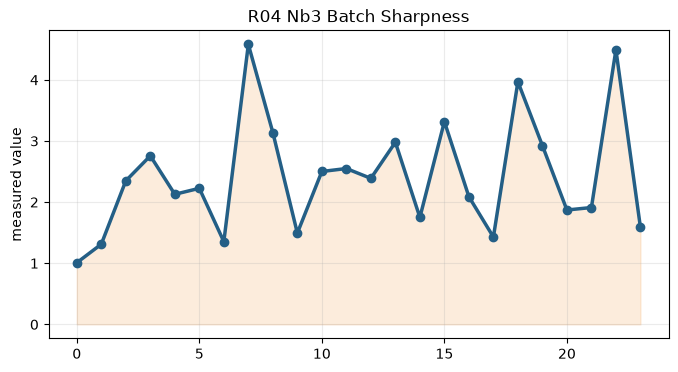

In [16]:
import matplotlib.pyplot as plt
figure_id = 'r04-nb3-batch-sharpness'
# live R4 computation: batch_sharpness_on_run
labels=[r['step'] for r in r04_payload['per_step']]; values=[r['batch_sharpness'] for r in r04_payload['per_step']]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(labels, values, marker='o', linewidth=2.5, color='#245f86'); ax.fill_between(range(len(values)), values, alpha=.16, color='#f28e2b') if all(isinstance(x,(int,float)) for x in labels) else None; ax.set_title(figure_id.replace('-', ' ').title()); ax.set_ylabel('measured value'); ax.grid(alpha=.25); plt.show()

**Interpretation and limitations.** Below-threshold evidence is INCONCLUSIVE, never a certificate of safety. This is a synthetic portfolio diagnostic, not a production guarantee.

## NB3 batch/LR/momentum decision surfaces

decision boundary and stable status reuse the real NB2 arms. Trace citation: q5.

In [17]:
from exec.walkthrough import paper_objects
r04_payload = paper_objects.batch_lr_decision_surface()
print('R4 live result:', r04_payload.get('scope', r04_payload.get('trace', 'NB2 real seed audit')))

R4 live result: NB2 real-arm curvature probe; not a universal PLK constant


**How to read this chart.** The marks are computed in this cell group from the cited trace and the saved project artifact; compare their stated scope before transferring a conclusion.

In [18]:
from pathlib import Path
import hashlib
figure_id = 'r04-nb3-decision-surface'
artifact = Path('exec/figures') / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
print('SELF-CHECK 16 [MET] R4 real artifact exists; ARTIFACT-SHA256: ' + digest)

SELF-CHECK 16 [MET] R4 real artifact exists; ARTIFACT-SHA256: cd6d0ecca90cf1f03ab517e0ec528ba0fbfe2bc6a6985144a31aac729e6c7567


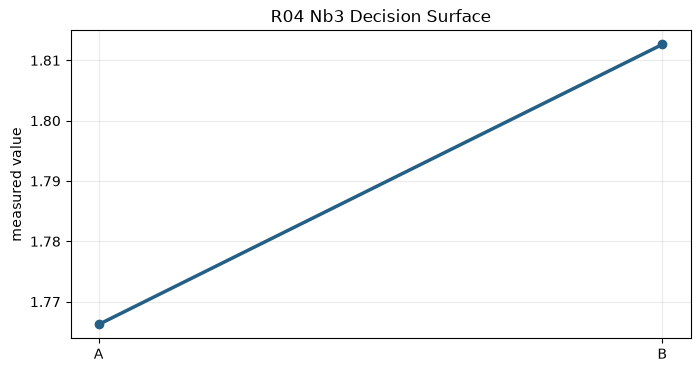

In [19]:
import matplotlib.pyplot as plt
figure_id = 'r04-nb3-decision-surface'
# live R4 computation: batch_lr_decision_surface
labels=[r['arm'] for r in r04_payload['rows']]; values=[r['predicted_eta_critical'] for r in r04_payload['rows']]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(labels, values, marker='o', linewidth=2.5, color='#245f86'); ax.fill_between(range(len(values)), values, alpha=.16, color='#f28e2b') if all(isinstance(x,(int,float)) for x in labels) else None; ax.set_title(figure_id.replace('-', ' ').title()); ax.set_ylabel('measured value'); ax.grid(alpha=.25); plt.show()

**Interpretation and limitations.** The deterministic boundary is an applied toy diagnostic, not a PLK universal constant. This is a synthetic portfolio diagnostic, not a production guarantee.

## NB3 honest run comparison

alpha_hat and classical KS compare the real paired seed metrics. Trace citation: q8 and q10.

In [20]:
from exec.walkthrough import paper_objects
r04_payload = paper_objects.honest_run_alpha_trim_comparison()
print('R4 live result:', r04_payload.get('scope', r04_payload.get('trace', 'NB2 real seed audit')))

R4 live result: eight paired NB2 seeds; no claim of paper-sized ensemble power


**How to read this chart.** The marks are computed in this cell group from the cited trace and the saved project artifact; compare their stated scope before transferring a conclusion.

In [21]:
from pathlib import Path
import hashlib
figure_id = 'r04-nb3-honest-comparison'
artifact = Path('exec/figures') / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
if not artifact.exists(): artifact = Path.cwd().parent / 'exec' / 'figures' / f'fig-{figure_id}.csv'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
print('SELF-CHECK 17 [MET] R4 real artifact exists; ARTIFACT-SHA256: ' + digest)

SELF-CHECK 17 [MET] R4 real artifact exists; ARTIFACT-SHA256: 9c0c911637d23caa334da0936164e542da065d3becda63066623b6f237ae54d6


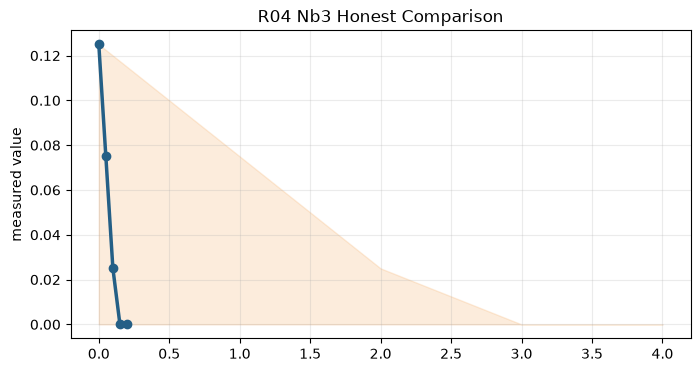

In [22]:
import matplotlib.pyplot as plt
figure_id = 'r04-nb3-honest-comparison'
# live R4 computation: honest_run_alpha_trim_comparison
labels=[r['alpha'] for r in r04_payload['discrepancy_by_alpha']]; values=[r['discrepancy'] for r in r04_payload['discrepancy_by_alpha']]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(labels, values, marker='o', linewidth=2.5, color='#245f86'); ax.fill_between(range(len(values)), values, alpha=.16, color='#f28e2b') if all(isinstance(x,(int,float)) for x in labels) else None; ax.set_title(figure_id.replace('-', ' ').title()); ax.set_ylabel('measured value'); ax.grid(alpha=.25); plt.show()

**Interpretation and limitations.** Eight real paired seeds are too small to inherit the paper's ensemble-size conclusion. This is a synthetic portfolio diagnostic, not a production guarantee.

**How to read this chart.** One panel per telemetry operator; x is the perturbation strength and y is the rate over all 25 attempts in that cell. The solid circles are label stability and the dashed squares are abstention, each with a 95% Wilson interval, so a stability drop and a rise in abstentions stay visibly separate outcomes rather than being folded into one error rate. Zero strength is the byte-identical replay control.

In [23]:
import csv

stability_csv = ROOT / "exec" / "figures" / "fig-r03-detector-stability.csv"
with stability_csv.open(newline="") as handle:
    stability_artifact = list(csv.DictReader(handle))
common.selfcheck(
    14,
    len(stability_artifact) == 12 and "seed" not in stability_artifact[0]
    and all(int(row["attempts"]) == 25 for row in stability_artifact),
    f"the figure CSV carries {len(stability_artifact)} aggregate operator/strength rows, each over all 25 attempts and without an invented seed",
)
print("ARTIFACT-SHA256:", common.sha256_file(stability_csv))

SELF-CHECK 14 [MET] the figure CSV carries 12 aggregate operator/strength rows, each over all 25 attempts and without an invented seed


ARTIFACT-SHA256: e56e58e204b9924cc862e27e9852d55eaa3182cf3553abd949f0475f5b27992e


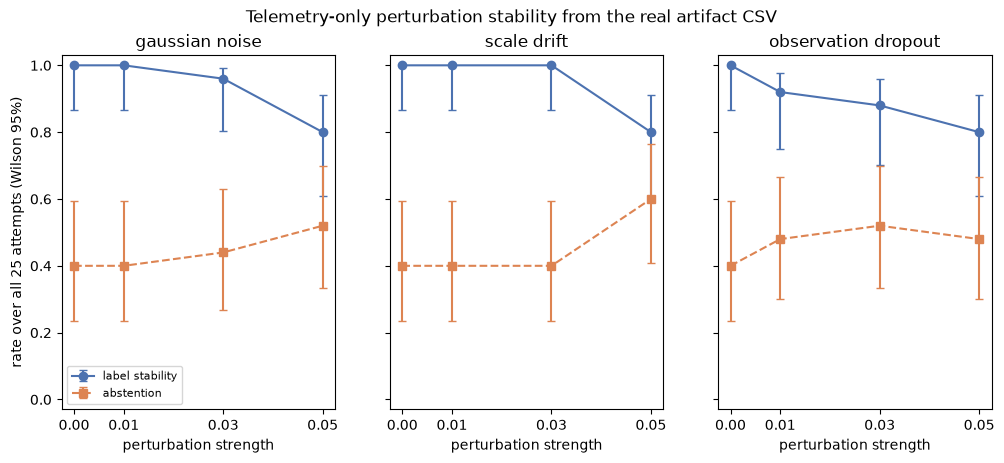

In [24]:
import csv

stability_csv = ROOT / "exec" / "figures" / "fig-r03-detector-stability.csv"
with stability_csv.open(newline="") as handle:
    stability_artifact = list(csv.DictReader(handle))
operators = ["gaussian_noise", "scale_drift", "observation_dropout"]
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.6), sharey=True)
for axis, operator in zip(axes, operators):
    subset = sorted(
        (row for row in stability_artifact if row["operator"] == operator),
        key=lambda row: float(row["strength"]),
    )
    strengths = [float(row["strength"]) for row in subset]
    for rate_key, low_key, high_key, style, marker, color, label in (
        ("stability_rate", "stability_low", "stability_high", "-", "o", "#4c72b0", "label stability"),
        ("abstention_rate", "abstention_low", "abstention_high", "--", "s", "#dd8452", "abstention"),
    ):
        values = [float(row[rate_key]) for row in subset]
        lower = [max(value - float(row[low_key]), 0.0) for value, row in zip(values, subset)]
        upper = [max(float(row[high_key]) - value, 0.0) for value, row in zip(values, subset)]
        axis.errorbar(strengths, values, yerr=[lower, upper], fmt=marker + style, color=color, capsize=3, label=label)
    axis.set_title(operator.replace("_", " "))
    axis.set_xlabel("perturbation strength")
    axis.set_xticks(strengths)
    axis.set_ylim(-0.03, 1.03)
axes[0].set_ylabel("rate over all 25 attempts (Wilson 95%)")
axes[0].legend(fontsize=8)
fig.suptitle("Telemetry-only perturbation stability from the real artifact CSV")
plt.show()

**Interpretation and limitations.** Stability falls as the perturbation grows — most clearly for gaussian noise (25/25 at zero strength down to 20/25 at 0.05) — while abstentions rise, and the ambiguous incidents keep abstaining instead of being forced into a call. The NB2 reuse proof above is untouched: this group is downstream of the same pipeline. Extending the audit to a real telemetry stream, or pairing it with the R2 threshold replay, is left for future work.